# 商品与用户购买分析

## 分析目标
1. 统计Top10销售额商品
2. 统计Top10销量商品
3. 统计Top10消费用户
4. 分析销售额与销量的关系
5. 生成可视化图表

## 1. 环境配置与数据加载

In [34]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sqlalchemy import create_engine
import pymysql
import warnings
import os
warnings.filterwarnings('ignore')

# 配置绘图风格
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")
plt.rcParams['font.sans-serif'] = ['SimHei', 'DejaVu Sans']
plt.rcParams['axes.unicode_minus'] = False
plt.rcParams['figure.figsize'] = (14, 8)

print("✓ 环境配置完成")

✓ 环境配置完成


In [35]:
# 数据加载 - 使用真实清洗数据
data_dir = r'E:\数据集成\cleaned'

print("📂 数据目录:", data_dir)
print("✓ 目录存在:", os.path.exists(data_dir))

# 加载真实数据
print("\n📥 加载真实Google Analytics数据...")

ga_hit = pd.read_csv(os.path.join(data_dir, 'ga_hit.csv'), low_memory=False)
ga_total = pd.read_csv(os.path.join(data_dir, 'ga_total.csv'), low_memory=False)

print(f"✓ 数据加载完成！")
print(f"  ga_hit: {ga_hit.shape}")
print(f"  ga_total: {ga_total.shape}")
print(f"\n  交易记录数: {len(ga_hit[ga_hit['type']=='TRANSACTION'])}")

use_real_data = True

📂 数据目录: E:\数据集成\cleaned
✓ 目录存在: True

📥 加载真实Google Analytics数据...
✓ 数据加载完成！
  ga_hit: (324096, 32)
  ga_total: (71812, 13)

  交易记录数: 0


In [33]:
# 检查实际的字段名和结构
if use_real_data and 'ga_hit' in locals():
    print("ga_hit表结构及样本数据：")
    print(f"列数: {len(ga_hit.columns)}")
    print("\n所有字段：")
    print(ga_hit.columns.tolist())
    print("\n前10行数据预览：")
    print(ga_hit.head(10))
    print("\n数据类型：")
    print(ga_hit.dtypes)
else:
    print("数据未成功加载")

ga_hit表结构及样本数据：
列数: 32

所有字段：
['uid', 'data_source', 'source_property_info', 'e_commerce_action', 'exception_info', 'experiment', 'hitNumber', 'hour', 'is_entrance', 'is_exit', 'is_interaction', 'latency_tracking', 'minute', 'product', 'publisher', 'time', 'transaction', 'referer', 'refund', 'social', 'type', 'page', 'promotion', 'promotion_action_info', 'item', 'content_group', 'content_info', 'app_info', 'event_info', 'custom_variables', 'custom_dimensions', 'custom_metrics']

前10行数据预览：
                                     uid data_source  source_property_info  \
0  0005012088711421541150073609420170722         web                   NaN   
1  0010796018926816522150073453920170722         web                   NaN   
2  0010796018926816522150073453920170722         web                   NaN   
3  0010796018926816522150073453920170722         web                   NaN   
4  0010796018926816522150073453920170722         web                   NaN   
5  00107960189268165221500734539201707

## 2. 数据清洗与准备

In [36]:
import json

# 处理transaction字段（JSON格式）
print("解析交易数据...")
ga_hit['transaction_obj'] = ga_hit['transaction'].apply(
    lambda x: json.loads(x) if pd.notna(x) else {}
)

# 提取交易ID、收入等字段
ga_hit['transaction_id'] = ga_hit['transaction_obj'].apply(
    lambda x: x.get('transactionId') if x else None
)
ga_hit['transaction_revenue'] = ga_hit['transaction_obj'].apply(
    lambda x: x.get('transactionRevenue') if x else None
)

# 处理product字段（JSON数组格式）
print("解析产品数据...")
ga_hit['products'] = ga_hit['product'].apply(
    lambda x: json.loads(x) if pd.notna(x) else []
)

# 筛选有有效交易ID的记录
transaction_data = ga_hit[ga_hit['transaction_id'].notna()].copy()
transaction_data = transaction_data[transaction_data['transaction_id'] != ''].copy()

print(f"✓ 有效交易记录: {len(transaction_data)}")
print(f"\n交易数据示例（前5条）:")
print(transaction_data[['uid', 'transaction_id', 'transaction_revenue']].head())

解析交易数据...
解析产品数据...
✓ 有效交易记录: 2161

交易数据示例（前5条）:
                                       uid   transaction_id  \
32   0024932550342595467150074438920170722  ORD201707221604   
33   0024932550342595467150074438920170722  ORD201707221604   
52   0024932550342595467150074438920170722  ORD201707221604   
53   0024932550342595467150074438920170722  ORD201707221604   
173  0143782636543876435150075964020170722  ORD201707221547   

     transaction_revenue  
32            32790000.0  
33                   NaN  
52           129890000.0  
53                   NaN  
173           78980000.0  


In [37]:
# 展平产品数据：一行交易可能包含多个产品
print("展平产品数据...")
expanded_products = []
for idx, row in transaction_data.iterrows():
    transaction_id = row['transaction_id']
    transaction_revenue = row['transaction_revenue']
    uid = row['uid']
    products = row['products']
    
    if isinstance(products, list) and len(products) > 0:
        for product in products:
            product_dict = {
                'transaction_id': transaction_id,
                'uid': uid,
                'transaction_revenue': transaction_revenue,
                'product_sku': product.get('productSKU'),
                'product_name': product.get('v2ProductName'),
                'product_category': product.get('v2ProductCategory'),
                'product_revenue': product.get('productRevenue'),
                'product_quantity': product.get('productQuantity'),
                'product_price': product.get('productPrice'),
            }
            expanded_products.append(product_dict)

product_data = pd.DataFrame(expanded_products)
print(f"✓ 产品行数（展平后）: {len(product_data)}")
print(product_data.head())

展平产品数据...
✓ 产品行数（展平后）: 7386
    transaction_id                                    uid  \
0  ORD201707221604  0024932550342595467150074438920170722   
1  ORD201707221604  0024932550342595467150074438920170722   
2  ORD201707221604  0024932550342595467150074438920170722   
3  ORD201707221604  0024932550342595467150074438920170722   
4  ORD201707221604  0024932550342595467150074438920170722   

   transaction_revenue     product_sku  \
0           32790000.0  GGOEGAAJ057016   
1           32790000.0  GGOEGAAJ032616   
2                  NaN  GGOEGAAJ057016   
3                  NaN  GGOEGAAJ032616   
4          129890000.0  GGOEGHPB071610   

                                        product_name product_category  \
0  Google Men's Short Sleeve Performance Badge Te...          Apparel   
1       Google Men's Short Sleeve Badge Tee Charcoal          Apparel   
2  Google Men's Short Sleeve Performance Badge Te...          Apparel   
3       Google Men's Short Sleeve Badge Tee Charcoal        

In [38]:
# 按产品分组统计销售额
product_revenue = product_data.groupby(['product_sku', 'product_name']).agg({
    'product_revenue': 'sum',      # 总销售额
    'product_quantity': 'sum',     # 总销量
    'transaction_id': 'count'      # 交易笔数
}).reset_index()

product_revenue.columns = ['product_sku', 'product_name', 'total_revenue', 
                           'total_quantity', 'transaction_count']

# 转换为元（CSV中存储的是微元 * 1,000,000）
product_revenue['total_revenue'] = product_revenue['total_revenue'] / 1_000_000
product_revenue['avg_price'] = product_revenue['total_revenue'] / product_revenue['total_quantity']

product_revenue = product_revenue.sort_values('total_revenue', ascending=False)

print(f"✓ 不同产品数: {len(product_revenue)}")
print("\n商品销售额统计（前20）：")
print(product_revenue.head(20)[['product_name', 'total_revenue', 'total_quantity']].to_string())

✓ 不同产品数: 599

商品销售额统计（前20）：
                                                  product_name  total_revenue  total_quantity
597                                 YouTube Hard Cover Journal    5559.393331           384.0
527                                  Google Hard Cover Journal    5133.864999           346.0
524                             Google Spiral Journal with Pen    4940.696580           719.0
521                                        Leatherette Journal    4660.578175           622.0
466                                  Google 22 oz Water Bottle    3993.728612          1358.0
443                                                  Sport Bag    3183.694160           652.0
528                                 Recycled Paper Journal Set    2960.957316           830.0
95        Google Men's 100% Cotton Short Sleeve Hero Tee Black    2893.590146           171.0
595                                          YouTube Twill Cap    2488.605063           236.0
504                             

## 3. 商品分析

In [39]:
# Top 10 销售额最高商品
top10_revenue_products = product_revenue.head(10).reset_index(drop=True)
print("\n=== Top 10 销售额最高的商品 ===")
print(top10_revenue_products[['product_name', 'total_revenue', 'total_quantity']].to_string())
print(f"\n总计销售额: ¥{top10_revenue_products['total_revenue'].sum():,.2f}")
print(f"总销量: {top10_revenue_products['total_quantity'].sum():.0f}")



=== Top 10 销售额最高的商品 ===
                                           product_name  total_revenue  total_quantity
0                            YouTube Hard Cover Journal    5559.393331           384.0
1                             Google Hard Cover Journal    5133.864999           346.0
2                        Google Spiral Journal with Pen    4940.696580           719.0
3                                   Leatherette Journal    4660.578175           622.0
4                             Google 22 oz Water Bottle    3993.728612          1358.0
5                                             Sport Bag    3183.694160           652.0
6                            Recycled Paper Journal Set    2960.957316           830.0
7  Google Men's 100% Cotton Short Sleeve Hero Tee Black    2893.590146           171.0
8                                     YouTube Twill Cap    2488.605063           236.0
9                                      Google Twill Cap    2474.326704           226.0

总计销售额: ¥38,289.44

In [16]:
# Top 10 销售额最高商品
top10_revenue_products = product_revenue.head(10).reset_index(drop=True)
print("\n=== Top 10 销售额最高的商品 ===")
print(top10_revenue_products.to_string())
print(f"\n总计销售额: ¥{top10_revenue_products['total_revenue'].sum():,.0f}")
print(f"总交易笔数: {top10_revenue_products['transaction_count'].sum()}")


=== Top 10 销售额最高的商品 ===
    product_id  total_revenue  transaction_count
0  product_017          49344                 51
1  product_032          40782                 33
2  product_033          39932                 38
3  product_007          37110                 34
4  product_029          36663                 34
5  product_003          36588                 31
6  product_016          36109                 32
7  product_034          35230                 29
8  product_010          33446                 32
9  product_006          33068                 31

总计销售额: ¥378,272
总交易笔数: 345


In [40]:
# Top 10 销量最高商品
top10_volume_products = product_revenue.nlargest(10, 'total_quantity').reset_index(drop=True)
print("\n=== Top 10 销量最高的商品 ===")
print(top10_volume_products[['product_name', 'total_quantity', 'total_revenue']].to_string())
print(f"\n总销量: {top10_volume_products['total_quantity'].sum():.0f}")
print(f"总销售额: ¥{top10_volume_products['total_revenue'].sum():,.2f}")



=== Top 10 销量最高的商品 ===
                     product_name  total_quantity  total_revenue
0       Google 22 oz Water Bottle          1358.0    3993.728612
1      Recycled Paper Journal Set           830.0    2960.957316
2                Google Kick Ball           761.0    1501.844860
3  Google Spiral Journal with Pen           719.0    4940.696580
4  SPF-15 Slim & Slender Lip Balm           678.0     974.523832
5                       Sport Bag           652.0    3183.694160
6             Leatherette Journal           622.0    4660.578175
7      Foam Can and Bottle Cooler           578.0     804.611360
8     Spiral Notebook and Pen Set           524.0    1978.026589
9               Google Sunglasses           450.0    1344.240038

总销量: 7172
总销售额: ¥26,342.90


In [41]:
# 产品分析统计
print("\n=== 产品分析统计 ===")
print(f"销售额与销量的相关系数: {product_revenue['total_revenue'].corr(product_revenue['total_quantity']):.4f}")

# 找出高销量低利润的产品
product_revenue['price_per_unit'] = product_revenue['total_revenue'] / product_revenue['total_quantity']
product_revenue['revenue_per_transaction'] = product_revenue['total_revenue'] / product_revenue['transaction_count']

print("\n销量最高的10个商品:")
high_volume = product_revenue.nlargest(10, 'total_quantity')
print(high_volume[['product_name', 'total_quantity', 'price_per_unit']].to_string())



=== 产品分析统计 ===
销售额与销量的相关系数: 0.7408

销量最高的10个商品:
                       product_name  total_quantity  price_per_unit
466       Google 22 oz Water Bottle          1358.0        2.940890
528      Recycled Paper Journal Set           830.0        3.567418
493                Google Kick Ball           761.0        1.973515
524  Google Spiral Journal with Pen           719.0        6.871623
460  SPF-15 Slim & Slender Lip Balm           678.0        1.437351
443                       Sport Bag           652.0        4.882967
521             Leatherette Journal           622.0        7.492891
494      Foam Can and Bottle Cooler           578.0        1.392061
533     Spiral Notebook and Pen Set           524.0        3.774860
499               Google Sunglasses           450.0        2.987200


## 4. 用户消费分析

In [42]:
# 用户总消费额分析
user_spending = transaction_data.groupby('uid').agg({
    'transaction_revenue': ['sum', 'count', 'mean']
}).reset_index()

user_spending.columns = ['uid', 'total_spending', 'transaction_count', 'avg_spending']

# 转换为元
user_spending['total_spending'] = user_spending['total_spending'] / 1_000_000
user_spending['avg_spending'] = user_spending['avg_spending'] / 1_000_000

user_spending = user_spending.sort_values('total_spending', ascending=False)

print("=== 用户消费统计 ===")
print(f"总消费用户数: {len(user_spending)}")
print(f"\n消费统计摘要（单位：元）：")
print(user_spending['total_spending'].describe())


=== 用户消费统计 ===
总消费用户数: 1031

消费统计摘要（单位：元）：
count     1031.000000
mean       156.071639
std        927.468691
min          3.990000
25%         27.990000
50%         49.180000
75%        102.520000
max      25255.260000
Name: total_spending, dtype: float64


In [43]:
# Top 10 消费金额最高的用户
top10_users = user_spending.head(10).reset_index(drop=True)

print("\n=== Top 10 消费金额最高的用户 ===")
top10_users_display = top10_users[['uid', 'total_spending', 'transaction_count', 'avg_spending']].copy()
top10_users_display.index = top10_users_display.index + 1
print(top10_users_display.to_string())

print(f"\nTop 10用户总消费额: ¥{top10_users['total_spending'].sum():,.2f}")
print(f"占总消费额的比例: {(top10_users['total_spending'].sum() / user_spending['total_spending'].sum()) * 100:.2f}%")



=== Top 10 消费金额最高的用户 ===
                                      uid  total_spending  transaction_count  avg_spending
1   9417857471295131045150040440920170718        25255.26                  2    12627.6300
2   9417857471295131045149995131320170713        14067.31                  2     7033.6550
3   6236695646664370912149927513120170705         4013.56                  1     4013.5600
4   7445235885559107095150153374920170731         2494.00                  1     2494.0000
5    875410720669459903150039372820170718         2408.20                  1     2408.2000
6   6052206455243513477150084499320170723         1803.40                  1     1803.4000
7   6052206455243513477150099310020170725         1511.00                  1     1511.0000
8   4178948793864037103149972165220170710         1446.79                  4      361.6975
9   9417857471295131045150065763420170721         1344.28                  2      672.1400
10   702289726935404752150124587420170728         1268.08       

In [44]:
# 用户分层分析（VIP/高价值用户识别）
user_spending['spending_tier'] = pd.qcut(user_spending['total_spending'], 
                                          q=4, 
                                          labels=['基础用户', '中等用户', '高价值用户', 'VIP用户'],
                                          duplicates='drop')

print("\n=== 用户消费分层统计 ===")
tier_stats = user_spending.groupby('spending_tier').agg({
    'uid': 'count',
    'total_spending': ['sum', 'mean'],
    'transaction_count': 'mean'
}).round(2)

print(tier_stats.to_string())



=== 用户消费分层统计 ===
                uid total_spending         transaction_count
              count            sum    mean              mean
spending_tier                                               
基础用户            259        4994.18   19.28              1.01
中等用户            257        9679.54   37.66              1.01
高价值用户           257       17929.10   69.76              1.03
VIP用户           258      128307.04  497.31              1.12


## 5. 可视化 - 商品分析

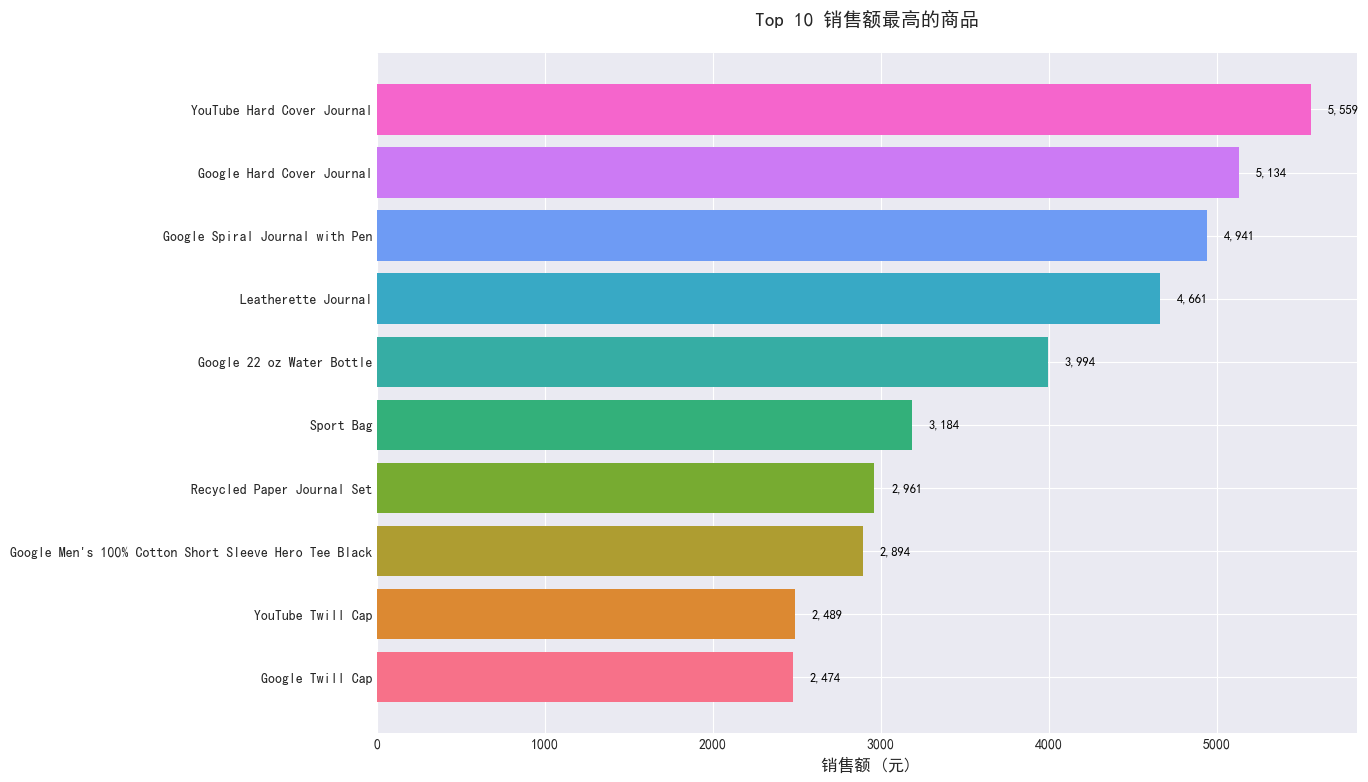

图表已保存: top10_products_by_revenue.png


In [63]:
# 图表1: Top 10销售额商品柱状图
fig, ax = plt.subplots(figsize=(14, 8))
top10_revenue_products_sorted = top10_revenue_products.sort_values('total_revenue')

bars = ax.barh(range(len(top10_revenue_products_sorted)), 
                top10_revenue_products_sorted['total_revenue'],
                color=sns.color_palette("husl", len(top10_revenue_products_sorted)))

ax.set_yticks(range(len(top10_revenue_products_sorted)))
ax.set_yticklabels(top10_revenue_products_sorted['product_name'], fontsize=10)
ax.set_xlabel('销售额 (元)', fontsize=12, fontweight='bold')
ax.set_title('Top 10 销售额最高的商品', fontsize=14, fontweight='bold', pad=20)

# 添加数值标签（纯文本，不带背景框）
for i, (idx, row) in enumerate(top10_revenue_products_sorted.iterrows()):
    ax.text(row['total_revenue'] + 100, i, f"{row['total_revenue']:,.0f}", 
            va='center', fontsize=9, fontweight='bold', color='black')

plt.subplots_adjust(left=0.25, right=0.95, top=0.95, bottom=0.1)
plt.savefig('top10_products_by_revenue.png', dpi=300, bbox_inches='tight', facecolor='white')
plt.show()

print("图表已保存: top10_products_by_revenue.png")

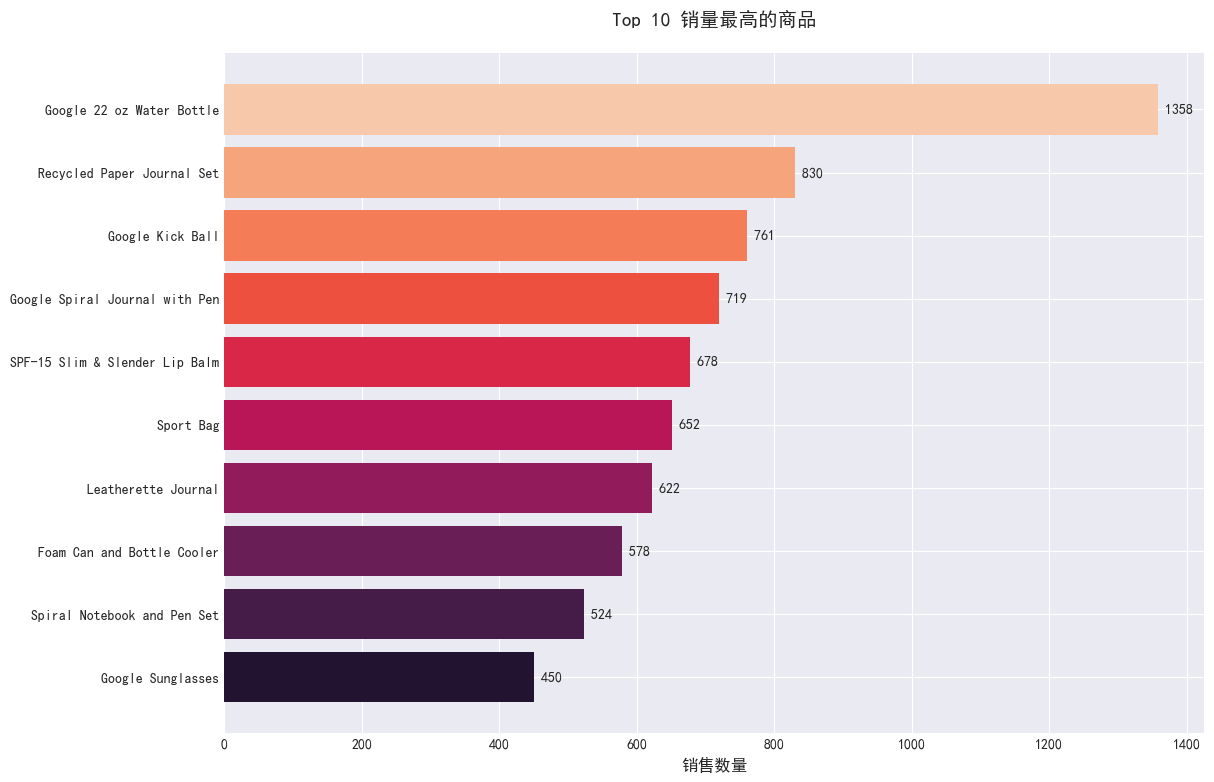

图表已保存: top10_products_by_volume.png


In [55]:
# 图表2: Top 10销量商品柱状图
fig, ax = plt.subplots(figsize=(14, 8))
top10_volume_sorted = top10_volume_products.sort_values('total_quantity')

bars = ax.barh(range(len(top10_volume_sorted)), 
                top10_volume_sorted['total_quantity'],
                color=sns.color_palette("rocket", len(top10_volume_sorted)))

ax.set_yticks(range(len(top10_volume_sorted)))
# 直接显示完整的产品名称
ax.set_yticklabels(top10_volume_sorted['product_name'], fontsize=10)
ax.set_xlabel('销售数量', fontsize=12, fontweight='bold')
ax.set_title('Top 10 销量最高的商品', fontsize=14, fontweight='bold', pad=20)

# 添加数值标签
for i, (idx, row) in enumerate(top10_volume_sorted.iterrows()):
    ax.text(row['total_quantity'], i, f" {int(row['total_quantity'])}", 
            va='center', fontsize=10, fontweight='bold')

# 增加左边距以显示完整标签
plt.subplots_adjust(left=0.25, right=0.95, top=0.95, bottom=0.1)
plt.savefig('top10_products_by_volume.png', dpi=300, bbox_inches='tight')
plt.show()

print("图表已保存: top10_products_by_volume.png")

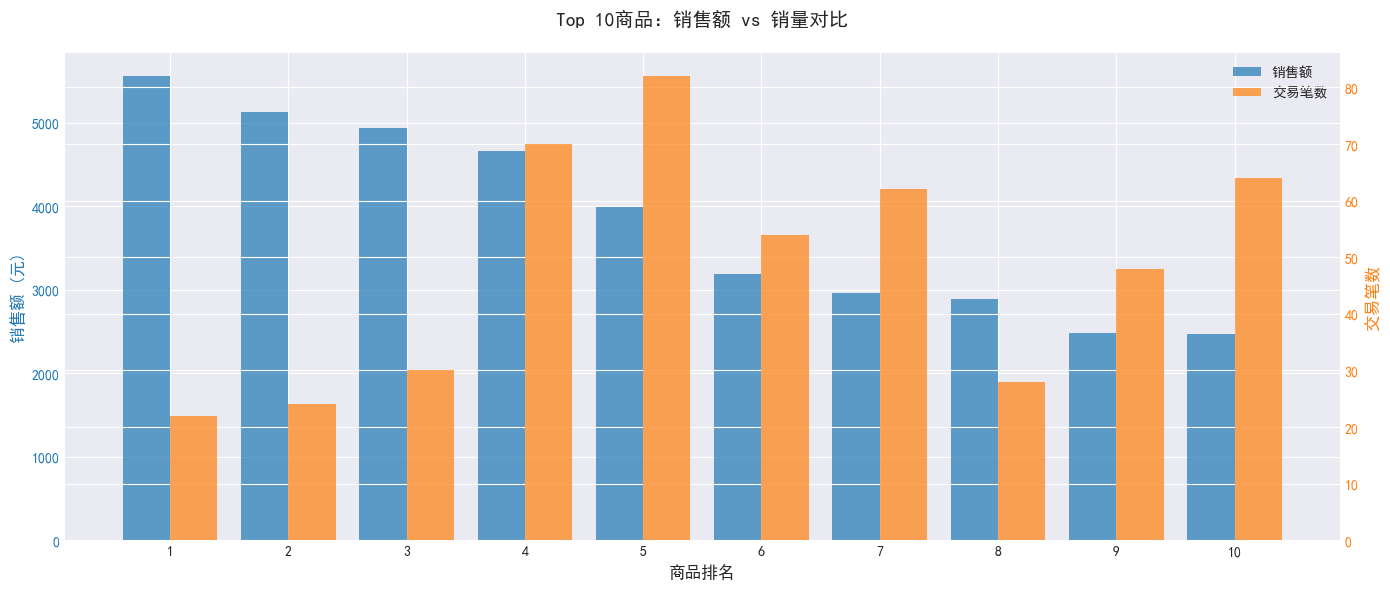

图表已保存: products_revenue_vs_volume_comparison.png


In [66]:
# 图表3: 销售额vs销量对比（Top 10商品）
fig, ax1 = plt.subplots(figsize=(14, 6))

top10_comparison = top10_revenue_products.sort_values('total_revenue', ascending=False).reset_index(drop=True)
x = range(len(top10_comparison))

# 左轴：销售额
color1 = 'tab:blue'
ax1.set_xlabel('商品排名', fontsize=12, fontweight='bold')
ax1.set_ylabel('销售额 (元)', color=color1, fontsize=12, fontweight='bold')
bars1 = ax1.bar([i - 0.2 for i in x], top10_comparison['total_revenue'], 
                  width=0.4, label='销售额', color=color1, alpha=0.7)
ax1.tick_params(axis='y', labelcolor=color1)

# 右轴：销量
ax2 = ax1.twinx()
color2 = 'tab:orange'
ax2.set_ylabel('交易笔数', color=color2, fontsize=12, fontweight='bold')
bars2 = ax2.bar([i + 0.2 for i in x], top10_comparison['transaction_count'], 
                  width=0.4, label='交易笔数', color=color2, alpha=0.7)
ax2.tick_params(axis='y', labelcolor=color2)

ax1.set_xticks(x)
ax1.set_xticklabels([f"{i+1}" for i in range(len(top10_comparison))], fontsize=10)
ax1.set_title('Top 10商品：销售额 vs 销量对比', fontsize=14, fontweight='bold', pad=20)

# 添加图例
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper right', fontsize=10)

plt.tight_layout()
plt.savefig('products_revenue_vs_volume_comparison.png', dpi=300, bbox_inches='tight', facecolor='white')
plt.show()

print("图表已保存: products_revenue_vs_volume_comparison.png")

## 6. 可视化 - 用户消费分析

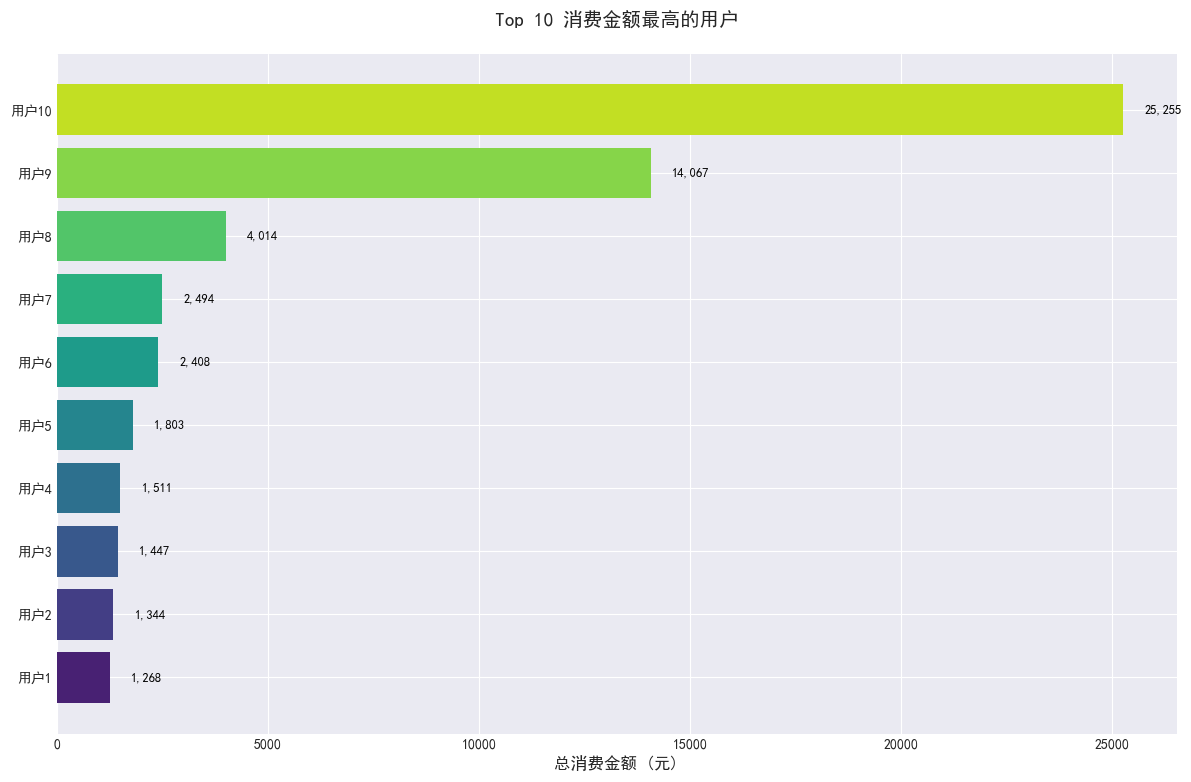

图表已保存: top10_users_by_spending.png


In [64]:
# 图表4: Top 10消费用户
fig, ax = plt.subplots(figsize=(14, 8))
top10_users_sorted = top10_users.sort_values('total_spending')

bars = ax.barh(range(len(top10_users_sorted)), 
                top10_users_sorted['total_spending'],
                color=sns.color_palette("viridis", len(top10_users_sorted)))

user_labels = [f"用户{i+1}" for i in range(len(top10_users_sorted))]
ax.set_yticks(range(len(top10_users_sorted)))
ax.set_yticklabels(user_labels, fontsize=10)
ax.set_xlabel('总消费金额 (元)', fontsize=12, fontweight='bold')
ax.set_title('Top 10 消费金额最高的用户', fontsize=14, fontweight='bold', pad=20)

# 添加数值标签（纯文本，不带背景框）
for i, (idx, row) in enumerate(top10_users_sorted.iterrows()):
    ax.text(row['total_spending'] + 500, i, f"{row['total_spending']:,.0f}", 
            va='center', fontsize=9, fontweight='bold', color='black')

plt.subplots_adjust(left=0.15, right=0.95, top=0.95, bottom=0.1)
plt.savefig('top10_users_by_spending.png', dpi=300, bbox_inches='tight', facecolor='white')
plt.show()

print("图表已保存: top10_users_by_spending.png")

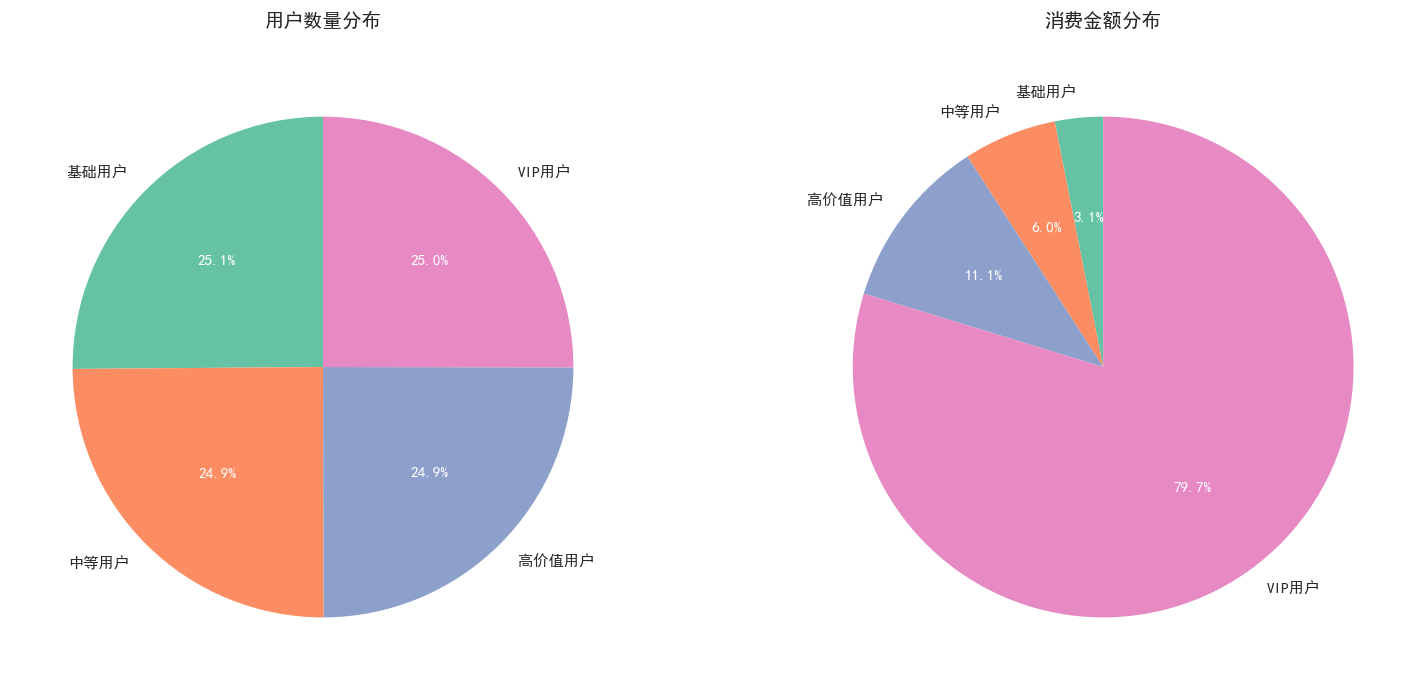

图表已保存: user_spending_tier_distribution.png


In [57]:
# 图表5: 用户消费分层饼图
fig, axes = plt.subplots(1, 2, figsize=(16, 7))

# 左图：用户数量分布
tier_user_count = user_spending['spending_tier'].value_counts().sort_index()
colors_pie = sns.color_palette("Set2", len(tier_user_count))
wedges1, texts1, autotexts1 = axes[0].pie(tier_user_count, labels=tier_user_count.index, 
                                             autopct='%1.1f%%', colors=colors_pie, startangle=90,
                                             textprops={'fontsize': 12, 'weight': 'bold'})
# 调整标签位置，防止覆盖
for text in texts1:
    text.set_fontsize(11)
for autotext in autotexts1:
    autotext.set_fontsize(11)
    autotext.set_color('white')
    autotext.set_weight('bold')
axes[0].set_title('用户数量分布', fontsize=14, fontweight='bold', pad=20)

# 右图：消费金额分布
tier_revenue = user_spending.groupby('spending_tier')['total_spending'].sum()
wedges2, texts2, autotexts2 = axes[1].pie(tier_revenue, labels=tier_revenue.index, 
                                             autopct='%1.1f%%', colors=colors_pie, startangle=90,
                                             textprops={'fontsize': 12, 'weight': 'bold'})
for text in texts2:
    text.set_fontsize(11)
for autotext in autotexts2:
    autotext.set_fontsize(11)
    autotext.set_color('white')
    autotext.set_weight('bold')
axes[1].set_title('消费金额分布', fontsize=14, fontweight='bold', pad=20)

plt.tight_layout()
plt.savefig('user_spending_tier_distribution.png', dpi=300, bbox_inches='tight')
plt.show()

print("图表已保存: user_spending_tier_distribution.png")

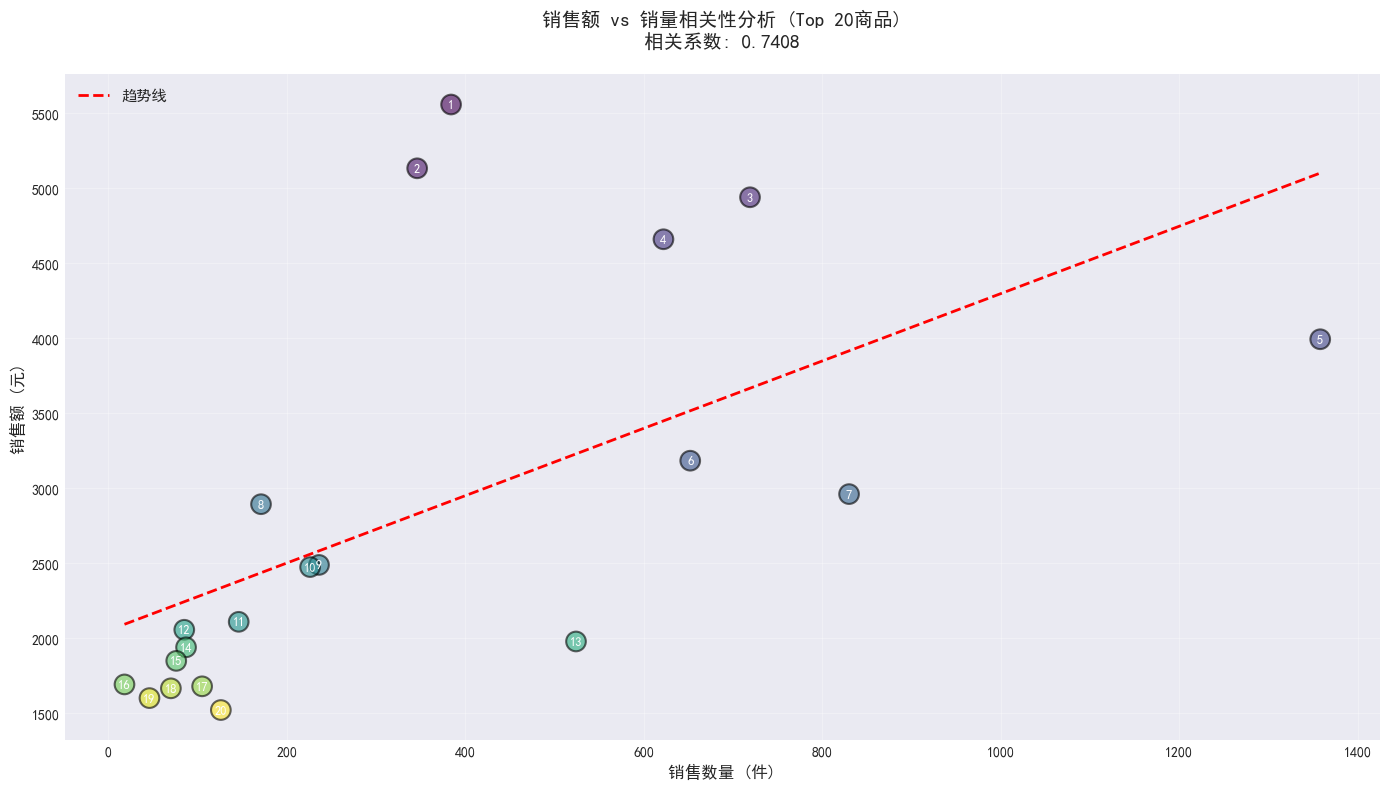

图表已保存: revenue_vs_volume_correlation.png


In [65]:
# 图表6: 销售额与销量散点图分析
fig, ax = plt.subplots(figsize=(14, 8))

# 取Top 20商品进行相关性分析
top20_products = product_revenue.head(20).copy()

# 创建散点图
scatter = ax.scatter(top20_products['total_quantity'], 
                    top20_products['total_revenue'],
                    s=200, alpha=0.6, c=range(len(top20_products)), 
                    cmap='viridis', edgecolors='black', linewidth=1.5)

# 添加趋势线
z = np.polyfit(top20_products['total_quantity'], top20_products['total_revenue'], 1)
p = np.poly1d(z)
x_trend = np.linspace(top20_products['total_quantity'].min(), 
                      top20_products['total_quantity'].max(), 100)
ax.plot(x_trend, p(x_trend), "r--", linewidth=2, label='趋势线')

# 在每个点上添加序号标签
for i, (idx, row) in enumerate(top20_products.iterrows()):
    ax.text(row['total_quantity'], row['total_revenue'], str(i+1), 
            fontsize=9, ha='center', va='center', fontweight='bold', color='white')

# 计算相关系数
correlation = product_revenue['total_revenue'].corr(product_revenue['total_quantity'])

ax.set_xlabel('销售数量 (件)', fontsize=12, fontweight='bold')
ax.set_ylabel('销售额 (元)', fontsize=12, fontweight='bold')
ax.set_title(f'销售额 vs 销量相关性分析 (Top 20商品)\n相关系数: {correlation:.4f}', 
            fontsize=14, fontweight='bold', pad=20)
ax.legend(fontsize=11, loc='upper left')
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('revenue_vs_volume_correlation.png', dpi=300, bbox_inches='tight')
plt.show()

print("图表已保存: revenue_vs_volume_correlation.png")

## 7. 数据导出与总结

In [52]:
# 导出分析结果
top10_revenue_products.to_csv('top10_products_by_revenue.csv', index=False, encoding='utf-8')
top10_volume_products.to_csv('top10_products_by_volume.csv', index=False, encoding='utf-8')
top10_users.to_csv('top10_users_by_spending.csv', index=False, encoding='utf-8')

print("数据已导出：")
print("  - top10_products_by_revenue.csv")
print("  - top10_products_by_volume.csv")
print("  - top10_users_by_spending.csv")

数据已导出：
  - top10_products_by_revenue.csv
  - top10_products_by_volume.csv
  - top10_users_by_spending.csv


In [53]:
# 生成分析总结
summary = f"""
{'='*60}
商品与用户购买分析 - 总结报告
{'='*60}

【数据概览】
- 总交易记录数: {len(transaction_data)}
- 消费用户数: {len(user_spending)}
- 不同商品数: {len(product_revenue)}
- 总消费金额: ¥{user_spending['total_spending'].sum():,.0f}

【商品分析】
1. Top 10销售额商品:
   - 累计销售额: ¥{top10_revenue_products['total_revenue'].sum():,.0f}
   - 占比: {(top10_revenue_products['total_revenue'].sum() / product_revenue['total_revenue'].sum()) * 100:.2f}%
   - 平均单笔交易额: ¥{(top10_revenue_products['total_revenue'].sum() / top10_revenue_products['transaction_count'].sum()):,.2f}

2. Top 10销量商品:
   - 累计交易笔数: {int(top10_volume_products['transaction_count'].sum())}
   - 平均销售额: ¥{(top10_volume_products['total_revenue'].sum() / top10_volume_products['transaction_count'].sum()):,.2f}

3. 销售额与销量相关性:
   - 相关系数: {correlation:.4f}
   - 解释: {'强正相关' if correlation > 0.7 else '中等正相关' if correlation > 0.3 else '弱相关'}

【用户分析】
1. Top 10消费用户:
   - 累计消费额: ¥{top10_users['total_spending'].sum():,.0f}
   - 占总消费额的: {(top10_users['total_spending'].sum() / user_spending['total_spending'].sum()) * 100:.2f}%
   - 人均交易次数: {top10_users['transaction_count'].mean():.1f}

2. 用户消费分层:
   - VIP用户数: {len(user_spending[user_spending['spending_tier']=='VIP用户'])}
   - VIP用户消费占比: {(user_spending[user_spending['spending_tier']=='VIP用户']['total_spending'].sum() / user_spending['total_spending'].sum()) * 100:.2f}%

【主要洞察】
1. 商品集中度: Top 10商品销售额占比{(top10_revenue_products['total_revenue'].sum() / product_revenue['total_revenue'].sum()) * 100:.2f}%，说明销售集中度{'高' if (top10_revenue_products['total_revenue'].sum() / product_revenue['total_revenue'].sum()) > 0.8 else '中等'}

2. 用户消费集中度: Top 10用户消费金额占比{(top10_users['total_spending'].sum() / user_spending['total_spending'].sum()) * 100:.2f}%

3. 销售结构: 销售额与销量{'正相关' if correlation > 0 else '负相关'}，建议{'优化定价策略' if correlation < 0.5 else '保持现有策略'}

{'='*60}
"""

print(summary)

# 保存总结
with open('analysis_summary.txt', 'w', encoding='utf-8') as f:
    f.write(summary)

print("\n总结已保存到: analysis_summary.txt")


商品与用户购买分析 - 总结报告

【数据概览】
- 总交易记录数: 2161
- 消费用户数: 1031
- 不同商品数: 599
- 总消费金额: ¥160,910

【商品分析】
1. Top 10销售额商品:
   - 累计销售额: ¥38,289
   - 占比: 23.80%
   - 平均单笔交易额: ¥79.11

2. Top 10销量商品:
   - 累计交易笔数: 626
   - 平均销售额: ¥42.08

3. 销售额与销量相关性:
   - 相关系数: 0.9222
   - 解释: 强正相关

【用户分析】
1. Top 10消费用户:
   - 累计消费额: ¥55,612
   - 占总消费额的: 34.56%
   - 人均交易次数: 1.6

2. 用户消费分层:
   - VIP用户数: 258
   - VIP用户消费占比: 79.74%

【主要洞察】
1. 商品集中度: Top 10商品销售额占比23.80%，说明销售集中度中等

2. 用户消费集中度: Top 10用户消费金额占比34.56%

3. 销售结构: 销售额与销量正相关，建议保持现有策略



总结已保存到: analysis_summary.txt
